<a href="https://colab.research.google.com/github/harsha-9977/AIML/blob/main/CV_mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q scikit-learn scikit-image torch torchvision joblib matplotlib pillow seaborn


📥 Loading EMNIST dataset...
✅ Dataset loaded: 8000 images, shape torch.Size([28, 28])
🔍 Extracting HOG features...


Extracting HOG: 100%|██████████| 8000/8000 [00:02<00:00, 3537.73it/s]


HOG feature extraction done in 2.27s, feature vector length = 324
🚀 Training SVM model...
✅ Model training completed!

🎯 Accuracy: 79.12%

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.72      0.63        36
           1       0.51      0.63      0.56        35
           2       0.80      0.89      0.85        37
           3       0.97      0.90      0.94        41
           4       0.88      0.82      0.85        34
           5       0.82      0.79      0.81        29
           6       0.84      0.89      0.86        36
           7       0.92      0.94      0.93        35
           8       0.75      0.84      0.79        32
           9       0.64      0.77      0.70        35
          10       0.76      0.84      0.80        31
          11       0.79      0.75      0.77        36
          12       0.83      0.86      0.85        35
          13       0.79      0.82      0.81        28
          14       0.87   

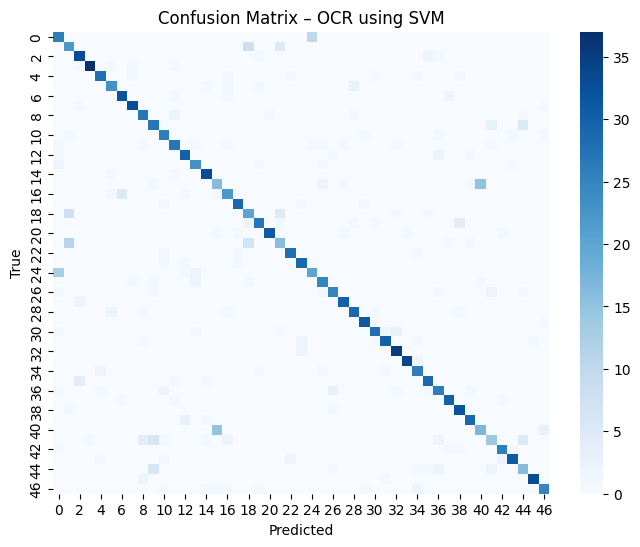

💾 Model saved in ./model folder


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


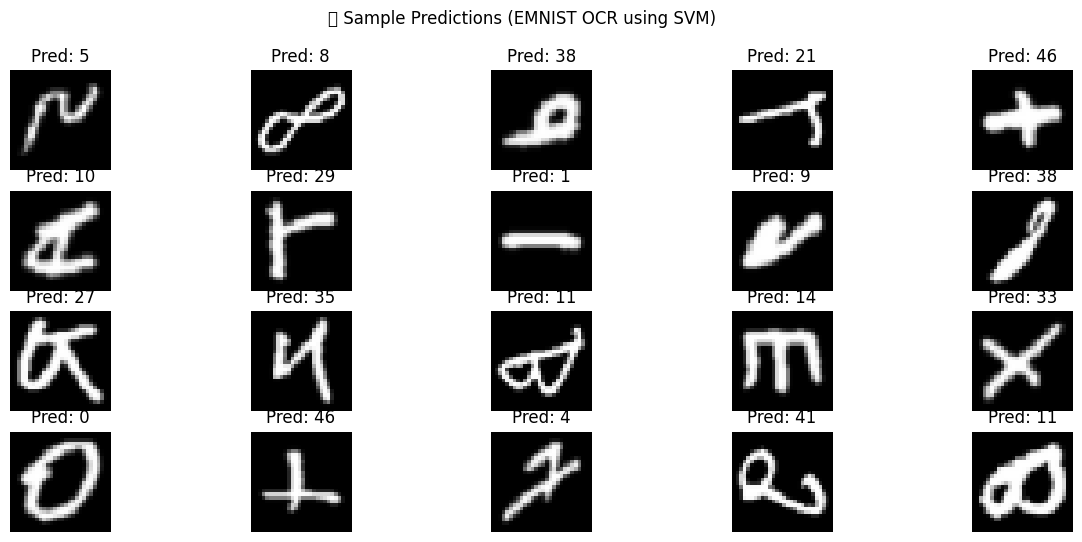

✅ OCR using SVM completed successfully!
Final Accuracy: 79.12% on EMNIST subset
Displayed 20 random predictions above.


In [6]:
# ==============================================================
# 🧠 OCR – Character Recognition using SVM (HOG + EMNIST)
# Deep Learning Techniques for Computer Vision – Mini Project
# Google Colab Version (T4 GPU optional)
# ==============================================================

# ✅ STEP 1: Install dependencies
!pip install -q scikit-learn scikit-image torch torchvision joblib matplotlib pillow seaborn tqdm

# ==============================================================
# ✅ STEP 2: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from PIL import Image
import torch
from torchvision import datasets, transforms
import joblib, time, os
from tqdm import tqdm

# ==============================================================
# ✅ STEP 3: Load EMNIST Dataset (digits + letters)
# ==============================================================
print("📥 Loading EMNIST dataset...")
transform = transforms.Compose([transforms.ToTensor()])
emnist_train = datasets.EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
emnist_test  = datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)

# Combine a subset for faster training
X = torch.cat([x for (x, _) in emnist_train][:6000] + [x for (x, _) in emnist_test][:2000])
y = torch.cat([torch.tensor([t for (_, t) in emnist_train][:6000])] + [torch.tensor([t for (_, t) in emnist_test][:2000])])

print(f"✅ Dataset loaded: {len(X)} images, shape {X[0].shape}")

# Convert tensors to numpy arrays
X_np = X.numpy().squeeze() * 255  # shape: (N,28,28)
y_np = y.numpy()

# ==============================================================
# ✅ STEP 4: Extract HOG Features
# ==============================================================
def extract_hog_features(images):
    feats = []
    for img in tqdm(images, desc="Extracting HOG"):
        feat = hog(img, orientations=9, pixels_per_cell=(7,7),
                   cells_per_block=(2,2), block_norm='L2-Hys')
        feats.append(feat)
    return np.array(feats)

print("🔍 Extracting HOG features...")
t0 = time.time()
X_feats = extract_hog_features(X_np)
t1 = time.time()
print(f"HOG feature extraction done in {t1-t0:.2f}s, feature vector length = {X_feats.shape[1]}")

# ==============================================================
# ✅ STEP 5: Train/Test Split and Scaling
# ==============================================================
X_train, X_test, y_train, y_test = train_test_split(X_feats, y_np, test_size=0.2, random_state=42, stratify=y_np)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ==============================================================
# ✅ STEP 6: Train SVM Model
# ==============================================================
print("🚀 Training SVM model...")
svm_model = svm.SVC(kernel='rbf', C=10, gamma=0.001)
svm_model.fit(X_train, y_train)
print("✅ Model training completed!")

# ==============================================================
# ✅ STEP 7: Evaluation
# ==============================================================
y_pred = svm_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues', annot=False)
plt.title('Confusion Matrix – OCR using SVM')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

# ==============================================================
# ✅ STEP 8: Save Model
# ==============================================================
os.makedirs("model", exist_ok=True)
joblib.dump(svm_model, "model/svm_ocr_emnist.joblib")
joblib.dump(scaler, "model/scaler_ocr_emnist.joblib")
print("💾 Model saved in ./model folder")

# ==============================================================
# ✅ STEP 9: Test Multiple Samples (Random Predictions)
# ==============================================================
num_samples = 20  # number of test samples to display
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15,6))
for i, idx in enumerate(indices):
    img = X_np[idx]
    sample_feat = hog(img, orientations=9, pixels_per_cell=(7,7),
                      cells_per_block=(2,2), block_norm='L2-Hys')
    pred = svm_model.predict(scaler.transform([sample_feat]))[0]
    plt.subplot(4,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred}")
    plt.axis('off')

plt.suptitle("🔍 Sample Predictions (EMNIST OCR using SVM)")
plt.show()

# ==============================================================
# ✅ STEP 10: Final Summary
# ==============================================================
print("✅ OCR using SVM completed successfully!")
print(f"Final Accuracy: {acc*100:.2f}% on EMNIST subset")
print("Displayed 20 random predictions above.")
